In [1]:
print("hola")

hola


In [2]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

BASE_URL = "http://new-service:8000"


# Fetch all documents
docs_response = requests.get(f"{BASE_URL}/documents/", params={"limit": 1000})
docs_response.raise_for_status()
documents = docs_response.json().get("documents", [])

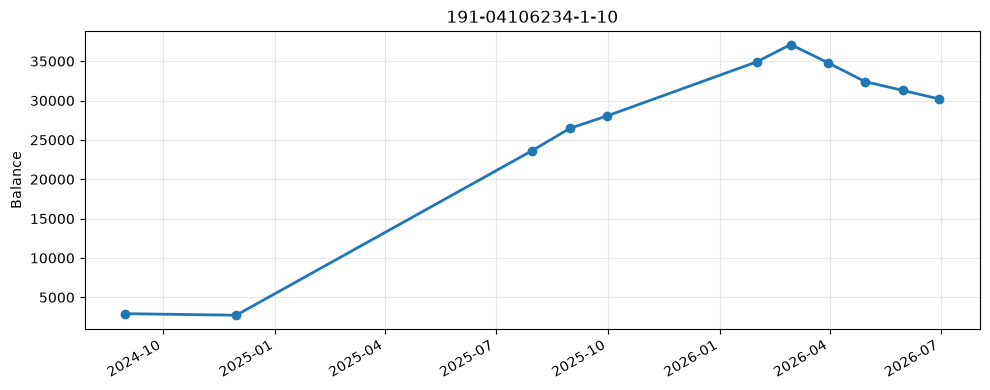

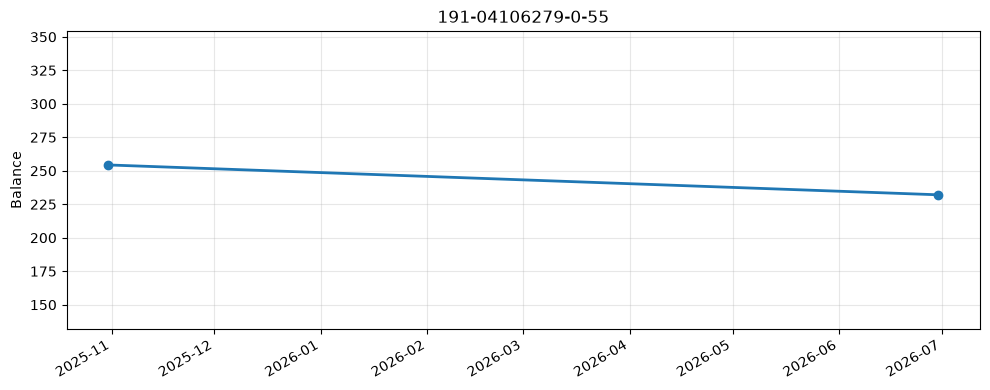

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

docs_df = pd.DataFrame(documents)

required_columns = {"end_date", "balance", "account"}

if not docs_df.empty and required_columns.issubset(docs_df.columns):

    # Convertir fechas inválidas a NaT
    docs_df["end_date"] = pd.to_datetime(
        docs_df["end_date"],
        errors="coerce",
    )

    # Convertir balances inválidos a NaN
    docs_df["balance"] = pd.to_numeric(
        docs_df["balance"],
        errors="coerce",
    )

    # Reemplazar infinito y menos infinito por NaN
    docs_df["balance"] = docs_df["balance"].replace(
        [np.inf, -np.inf],
        np.nan,
    )

    # Eliminar filas que no se pueden graficar
    docs_df = docs_df.dropna(
        subset=["end_date", "balance", "account"],
    )

    if docs_df.empty:
        print("No hay datos válidos para graficar.")

    else:
        for account, group in docs_df.groupby("account"):
            group = group.sort_values("end_date").copy()

            if group.empty:
                continue

            ymin = group["balance"].min()
            ymax = group["balance"].max()

            # Validación adicional
            if not np.isfinite(ymin) or not np.isfinite(ymax):
                print(f"Se omitió la cuenta {account}: límites inválidos.")
                continue

            balance_range = ymax - ymin

            # Si todos los valores son iguales, aplica un margen mínimo
            margin = max(abs(balance_range) * 0.05, 100)

            fig, ax = plt.subplots(figsize=(10, 4))

            ax.plot(
                group["end_date"],
                group["balance"],
                marker="o",
                linewidth=2,
            )

            ax.set_title(str(account))
            ax.set_xlabel("")
            ax.set_ylabel("Balance")
            ax.set_ylim(
                ymin - margin,
                ymax + margin,
            )
            ax.grid(True, alpha=0.3)

            fig.autofmt_xdate()
            plt.tight_layout()
            plt.show()
            plt.close(fig)

else:
    missing_columns = required_columns.difference(docs_df.columns)

    if docs_df.empty:
        print("El DataFrame está vacío.")
    else:
        print(f"Faltan columnas requeridas: {missing_columns}")